![image](https://github.com/eWaterCycle/ewatercycle/raw/main/docs/examples/logo.png)

# Generate forcing in eWaterCycle with ESMValTool

This notebooks shows how to generate forcing data for PCR-GLOBWB model using ERA5 data and [ESMValTool hydrological recipes](https://docs.esmvaltool.org/en/latest/recipes/recipe_hydrology.html#pcr-globwb). More information about data, configuration and installation instructions can be found in the [System setup](https://ewatercycle.readthedocs.io/en/latest/system_setup.html) in the eWaterCycle documentation.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

logger = logging.getLogger("esmvalcore")
logger.setLevel(logging.WARNING)

In [2]:
import xarray as xr
from rich import print

import ewatercycle.forcing

Forcing for PCRGlobWB is created using the ESMValTool recipe. It produces one file per each variable: temperature, and precipitation. You can set the start and end date, and the region. See [eWaterCycle documentation](https://ewatercycle.readthedocs.io/en/latest/apidocs/ewatercycle.forcing.html#submodules) for more information. 

In [3]:
clonemap_extents = {
    "Doring": {"latitude": (-34.5, -30.0), "longitude": (16.5, 22.5)},
    "Great_Kei": {"latitude": (-34.5, -30.0), "longitude": (24.0, 30.0)},
    "Merrimack": {"latitude": (40.5, 45.0), "longitude": (-73.5, -69.0)},
    "Meuse": {"latitude": (46.5, 52.5), "longitude": (1.5, 7.5)},
    "Rhine": {"latitude": (45.0, 54.0), "longitude": (3.0, 13.5)},
    "Savannah": {"latitude": (30.0, 36), "longitude": (-85.5, -79.5)},
}


In [4]:
catchment = "Rhine"

In [5]:
# Set the extent of the forcing data suffiently larger than the clonemap.
esmvaltool_padding = 1.5  # degrees lat/lon
x0, x1 = clonemap_extents[catchment]["longitude"]
y0, y1 = clonemap_extents[catchment]["latitude"]


In [6]:
cmip_dataset_observation = {
    "dataset": "MPI-ESM1-2-HR",
    "project": "CMIP6",
    "grid": "gn",
    "exp": "historical",
    "ensemble": "r3i1p1f1",
}
# r1i1p1f1

In [7]:
pcrglobwb_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].generate(
    dataset=cmip_dataset_observation,
    start_time="1990-01-01T00:00:00Z",
    end_time="1992-12-31T00:00:00Z",
    shape="./data/Rhine/Rhine.shp",
    extract_region={
        "start_latitude": y0 - esmvaltool_padding,
        "end_latitude": y1 + esmvaltool_padding,
        "start_longitude": x0 - esmvaltool_padding,
        "end_longitude": x1 + esmvaltool_padding,
        },
    start_time_climatology="1990-01-01T00:00:00Z",
    end_time_climatology="1992-01-01T00:00:00Z",
)

In [8]:
print(pcrglobwb_forcing)

PCRGlobWBForcing(
    start_time='1990-01-01T00:00:00Z',
    end_time='1992-12-31T00:00:00Z',
    directory=PosixPath('/home/rhut/repos/ewatercycle-pcrglobwb/docs/esmvaltool_output/ewcrepr5cwkbb2_20240530_1113
57/work/diagnostic/script'),
    shape=PosixPath('/home/rhut/repos/ewatercycle-pcrglobwb/docs/esmvaltool_output/ewcrepr5cwkbb2_20240530_111357/w
ork/diagnostic/script/data/Rhine/Rhine.shp'),
    filenames={},
    precipitationNC='pcrglobwb_CMIP6_MPI-ESM1-2-HR_day_historical_r3i1p1f1_pr_gn_1990-1992_Rhine.nc',
    temperatureNC='pcrglobwb_CMIP6_MPI-ESM1-2-HR_day_historical_r3i1p1f1_tas_gn_1990-1992_Rhine.nc'
)

### Plot forcing

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1461, lat: 12, lon: 15, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 12kB 1989-01-01 1989-01-02 ... 1992-12-31
  * lat        (lat) float32 48B 54.7 53.77 52.83 51.9 ... 46.29 45.35 44.42
  * lon        (lon) float32 60B 1.876 2.813 3.751 4.688 ... 13.13 14.06 15.0
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 1MB 280.0 279.6 279.4 ... 281.7 278.8
    time_bnds  (time, bnds) datetime64[ns] 23kB 1988-12-31T12:00:00 ... 1992-...
    lat_bnds   (lat, bnds) float32 96B 55.17 54.23 54.23 ... 44.88 44.88 43.95
    lon_bnds   (lon, bnds) float32 120B 1.406 2.344 2.344 ... 14.53 14.53 15.47
Attributes: (12/46)
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36523.0
    cmor_version:           3.5.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    table_info:             Creation Date:(09 May 2019) MD5:e6ef8ececc8f33864...
    title:                  MPI-ESM1-2-HR output prepared for CMIP6
    variable_id:            tas
    variant_label:          r3i1p1f1
    Conventions:            CF-1.7
    caption:                Forcings for the PCR-GLOBWB hydrological model.

------------------------

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1461, lat: 12, lon: 15, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 12kB 1989-01-01 1989-01-02 ... 1992-12-31
  * lat        (lat) float32 48B 54.7 53.77 52.83 51.9 ... 46.29 45.35 44.42
  * lon        (lon) float32 60B 1.876 2.813 3.751 4.688 ... 13.13 14.06 15.0
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 1MB 0.001295 0.001539 ... 0.005529
    time_bnds  (time, bnds) datetime64[ns] 23kB 1988-12-31T12:00:00 ... 1992-...
    lat_bnds   (lat, bnds) float32 96B 55.17 54.23 54.23 ... 44.88 44.88 43.95
    lon_bnds   (lon, bnds) float32 120B 1.406 2.344 2.344 ... 14.53 14.53 15.47
Attributes: (12/47)
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  36523.0
    cmor_version:           3.5.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    table_info:             Creation Date:(09 May 2019) MD5:e6ef8ececc8f33864...
    title:                  MPI-ESM1-2-HR output prepared for CMIP6
    variable_id:            pr
    variant_label:          r3i1p1f1
    Conventions:            CF-1.7
    caption:                Forcings for the PCR-GLOBWB hydrological model.

------------------------

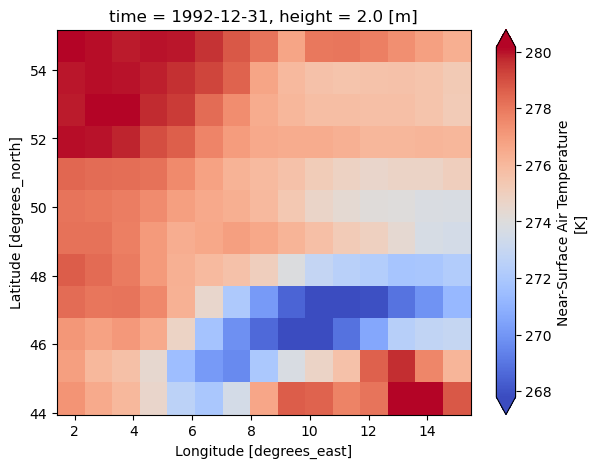

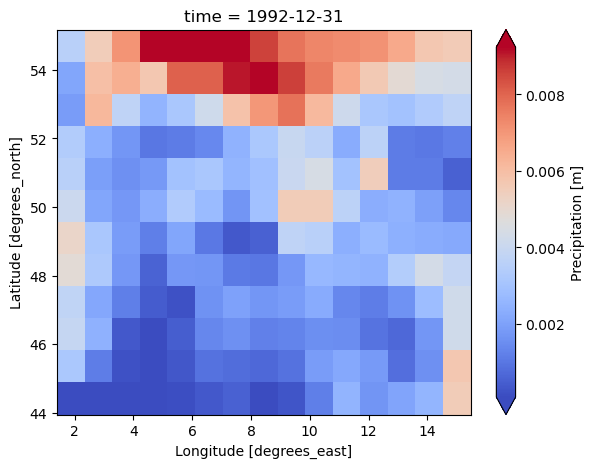

In [9]:
for file_name in [pcrglobwb_forcing.temperatureNC, pcrglobwb_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{pcrglobwb_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)